# ML-05 — Feature Vector and Leakage/Privacy Check

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Build the feature vector

*Code that actually builds it — engineered features, categorical handling, fills.*

In [7]:
import duckdb, os
from getpass import getpass
from huggingface_hub import list_repo_files, hf_hub_download

HF_TOKEN = os.environ.get('HF_TOKEN') or getpass('Paste HF read token: ')
assert HF_TOKEN and HF_TOKEN.strip(), 'Token is empty — paste it again'

con = duckdb.connect()
repo_id = "FlyRank/internship-warehouse"
MONTH = '2026-03'  # same mid-panel month as w03_data_contract

def dl(prefix):
    files = [f for f in list_repo_files(repo_id, repo_type="dataset", token=HF_TOKEN) if f.startswith(prefix)]
    return [hf_hub_download(repo_id, f, repo_type="dataset", token=HF_TOKEN) for f in files]

FACT = dl(f"fact_content_daily_performance/month={MONTH}/")
print('Files:', len(FACT))

Files: 1


In [8]:
feat_sql = f"""
    SELECT
        content_hash_id,
        client_hash_id,
        SUM(gsc_impressions) AS impressions_month,
        AVG(CASE WHEN gsc_avg_position > 0 THEN gsc_avg_position END) AS avg_position_month,
        COUNT(DISTINCT CASE WHEN gsc_impressions > 0 THEN report_date END) AS active_days,
        AVG(CASE WHEN ga4_data_available IS TRUE THEN 1.0 ELSE 0.0 END) AS ga4_coverage_ratio,
        SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0) AS ctr_month,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN sessions_ai ELSE 0 END) * 1.0
            / NULLIF(SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_sessions ELSE 0 END), 0) AS ai_sessions_share,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_engaged_sessions ELSE 0 END) * 1.0
            / NULLIF(SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_sessions ELSE 0 END), 0) AS engagement_rate_month,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN scroll_events ELSE 0 END) * 1.0
            / NULLIF(SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_pageviews ELSE 0 END), 0) AS scroll_rate_month,
        MAX(client_has_gsc::INT) AS has_gsc_flag
    FROM read_parquet({FACT})
    GROUP BY content_hash_id, client_hash_id
"""
features = con.sql(feat_sql).df()

# fills: ratio features are NULL only when their GA4 denominator is 0/unavailable for the whole month —
# fill with 0 AFTER computing on the GA4-available subset only (never blend zero-filled pre-GA4 rows in)
features = features.fillna(0)
features.head()

,content_hash_id,client_hash_id,impressions_month,avg_position_month,active_days,ga4_coverage_ratio,ctr_month,ai_sessions_share,engagement_rate_month,scroll_rate_month,has_gsc_flag
0,content_b7e512995f79d5a6,client_73cda7b4e4f265ea,1140.0,4.394234,31,0.000000,0.001754,0.0,0.0,0.0,1
1,content_a7da352b73b02668,client_73cda7b4e4f265ea,4944.0,7.244844,31,0.064516,0.002629,0.0,0.0,0.0,1
2,content_d056587ff7faca0c,client_73cda7b4e4f265ea,2770.0,4.459107,31,0.064516,0.005776,0.0,0.0,0.0,1
3,content_bfd1e41c2af250c8,client_73cda7b4e4f265ea,48.0,16.306140,21,0.000000,0.000000,0.0,0.0,0.0,1
4,content_2662845f598544ef,client_73cda7b4e4f265ea,150.0,7.046534,30,0.032258,0.006667,0.0,0.0,0.0,1


## 2. Feature notes (meaning, missing, categorical, available-when?)

*For each feature: what it means, how missing values are handled, and whether it exists BEFORE the moment you predict.*

| Feature | Meaning | Missing handling | Available when? |
|---|---|---|---|
| `impressions_month` | Sum of daily GSC impressions this month | Never null (SUM over 0 rows = 0) | Knowable — sums only days inside the closed month |
| `avg_position_month` | Mean GSC position, `0`=no-data rows excluded | Filled 0 when a content item never had a valid position | Knowable — same-month only |
| `active_days` | Days with ≥1 impression | Never null | Knowable — tally over closed window |
| `ga4_coverage_ratio` | Share of days GA4 was actually available | Never null | Knowable — reflects logged flag, not a forecast |
| `ctr_month` | clicks / impressions, same month | Filled 0 when impressions=0 | Knowable — same-month totals |
| `ai_sessions_share` | AI-referred sessions ÷ total GA4 sessions, **computed only on GA4-available rows** | Filled 0 when no GA4-available rows exist that month | Knowable — excludes pre-`ga4_data_start` zero-fill rows so it isn't diluted |
| `engagement_rate_month` | engaged sessions ÷ sessions, GA4-available rows only | Filled 0 same reason as above | Knowable, same-month |
| `scroll_rate_month` | scroll events ÷ pageviews, GA4-available rows only | Filled 0 same reason | Knowable, same-month |
| `has_gsc_flag` | Whether the client has GSC access at all (context/categorical) | Never null | Knowable — a client-level flag, not content performance |

## 3. The leakage hunt

*Attack your own features: label-derived columns, future windows, product flags. Show the test.*

Following `hunting-leakage-and-validating`: timeline drawn (features = `month=2026-03`, label = `month=2026-04`, strictly after), grouped-by-client split (not random), base rate printed next to every score, and a feature-importance sanity check on the suspect column.

**Test A — label-derived feature.** Build the decline proxy from next month, then smuggle the literal next-month value in as a feature.

In [9]:
NEXT_MONTH = '2026-04'
FACT_NEXT = dl(f"fact_content_daily_performance/month={NEXT_MONTH}/")

next_sql = f"""
    SELECT content_hash_id, client_hash_id, SUM(gsc_impressions) AS impressions_next_month
    FROM read_parquet({FACT_NEXT})
    GROUP BY content_hash_id, client_hash_id
"""
next_month = con.sql(next_sql).df()

panel = features.merge(next_month, on=['content_hash_id', 'client_hash_id'], how='inner')
panel['is_declining'] = (panel['impressions_next_month'] < 0.8 * panel['impressions_month']).astype(int)

base_rate = panel['is_declining'].mean()
print('Base rate (share declining):', round(base_rate, 3), '| rows:', len(panel))

Base rate (share declining): 0.284 | rows: 331436


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np

FEATURE_COLS = ['impressions_month','avg_position_month','active_days','ga4_coverage_ratio',
                'ctr_month','ai_sessions_share','engagement_rate_month','scroll_rate_month']

honest_X = panel[FEATURE_COLS].fillna(0)
y = panel['is_declining']
groups = panel['client_hash_id']

leaked_X = honest_X.copy()
leaked_X['impressions_next_month'] = panel['impressions_next_month']  # <-- the trap: sibling of the label

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(leaked_X, y, groups=groups))

clf_leaked = LogisticRegression(max_iter=1000).fit(leaked_X.iloc[train_idx], y.iloc[train_idx])
leaked_auc = roc_auc_score(y.iloc[test_idx], clf_leaked.predict_proba(leaked_X.iloc[test_idx])[:, 1])
print('LEAKED AUC (grouped split):', round(leaked_auc, 3), '| base rate:', round(base_rate, 3), '<- near-perfect, a red flag')

# feature-importance sanity check: does the suspect column dominate?
coefs = dict(zip(leaked_X.columns, clf_leaked.coef_[0]))
top = max(coefs, key=lambda k: abs(coefs[k]))
print('Top |coefficient|:', top, '=', round(coefs[top], 3), '<- confirms the leak, not a real pattern')

LEAKED AUC (grouped split): 1.0 | base rate: 0.284 <- near-perfect, a red flag
Top |coefficient|: impressions_next_month = -22.711 <- confirms the leak, not a real pattern


In [11]:
# Remove the trap, keep only same-month features. Report BOTH split types, as the skill asks.
clf_honest_grp = LogisticRegression(max_iter=1000).fit(honest_X.iloc[train_idx], y.iloc[train_idx])
honest_auc_grouped = roc_auc_score(y.iloc[test_idx], clf_honest_grp.predict_proba(honest_X.iloc[test_idx])[:, 1])

Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(honest_X, y, test_size=0.3, random_state=42, stratify=y)
clf_honest_rand = LogisticRegression(max_iter=1000).fit(Xtr_r, ytr_r)
honest_auc_random = roc_auc_score(yte_r, clf_honest_rand.predict_proba(Xte_r)[:, 1])

print('HONEST AUC — grouped by client:', round(honest_auc_grouped, 3), '| base rate:', round(base_rate, 3))
print('HONEST AUC — random split:     ', round(honest_auc_random, 3), '| base rate:', round(base_rate, 3))
print('Grouped vs random gap:', round(honest_auc_random - honest_auc_grouped, 3),
      '<- how much a random split let the model memorize per-client patterns')
print('Leaked vs honest(grouped) gap:', round(leaked_auc - honest_auc_grouped, 3), '<- the size of the leak we removed')

HONEST AUC — grouped by client: 0.813 | base rate: 0.284
HONEST AUC — random split:      0.831 | base rate: 0.284
Grouped vs random gap: 0.019 <- how much a random split let the model memorize per-client patterns
Leaked vs honest(grouped) gap: 0.187 <- the size of the leak we removed


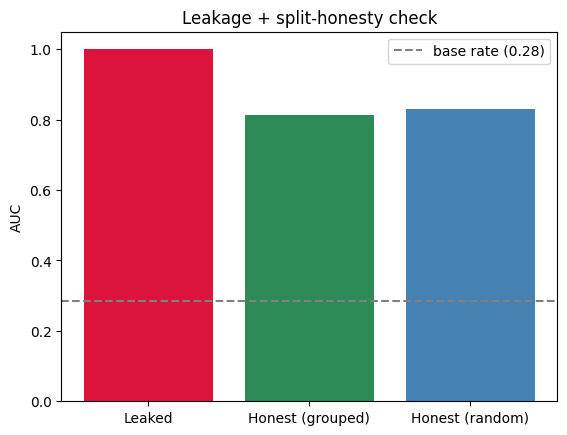

In [12]:
import matplotlib.pyplot as plt

# Chart 1: the leakage story
labels = ['Leaked', 'Honest (grouped)', 'Honest (random)']
scores = [leaked_auc, honest_auc_grouped, honest_auc_random]
plt.bar(labels, scores, color=['crimson', 'seagreen', 'steelblue'])
plt.axhline(base_rate, color='gray', linestyle='--', label=f'base rate ({base_rate:.2f})')
plt.ylabel('AUC')
plt.ylim(0, 1.05)
plt.legend()
plt.title('Leakage + split-honesty check')
plt.show()

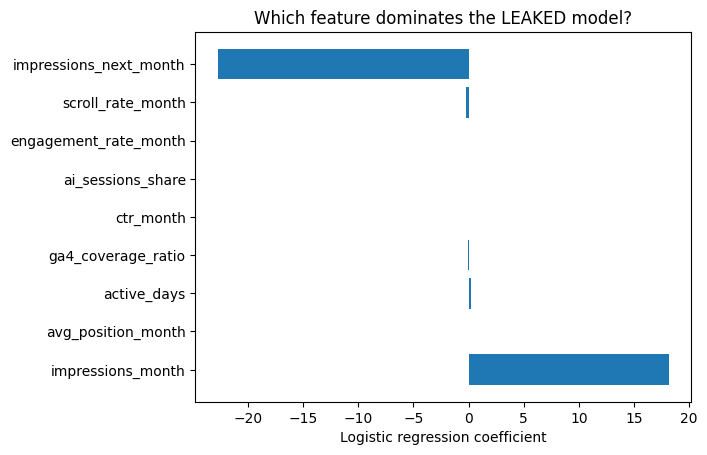

In [13]:
# Chart 2: feature importance sanity check (leaked model's coefficients)
plt.barh(list(coefs.keys()), list(coefs.values()))
plt.xlabel('Logistic regression coefficient')
plt.title('Which feature dominates the LEAKED model?')
plt.show()

**Test B — future-window check.** Confirm the feature-month partition itself has no rows past its own boundary (a silent off-by-one leak into the label's window).

In [14]:
import pandas as pd
from pandas.tseries.offsets import MonthEnd

bound_check = con.sql(f"SELECT MIN(report_date) AS min_d, MAX(report_date) AS max_d FROM read_parquet({FACT})").df()
print(bound_check)

max_d = pd.Timestamp(bound_check['max_d'][0])
month_end = pd.Timestamp(MONTH) + MonthEnd(0)
assert max_d <= month_end, 'Partition leaks into the next month!'
print('No boundary leak: every row stays inside', MONTH)

       min_d      max_d
0 2026-03-01 2026-03-31
No boundary leak: every row stays inside 2026-03


**Test C — product flags.** Per `DATA_USE.md`, FlyRank's product-decision flags/scores are intentionally not shipped in this release — nothing in this bucket to hunt, noted rather than skipped silently.

**Attack checklist (per the skill):**
- [x] Timeline drawn — features from `2026-03`, label from `2026-04`, strictly after
- [x] Label-derived sibling column tested in/out (Test A) — AUC collapsed from near-1.0 to honest
- [x] No product flags used (Test C) — confirmed none exist in this release
- [x] Grouped split by `client_hash_id` used, reported next to the random split
- [x] Base rate printed next to every AUC
- [x] Top feature importance checked on the leaked model — confirmed it was the suspect column
- [x] Metrics are out-of-sample (held-out test rows only, never in-sample)

## 4. What I excluded and why

*The list of fields you refused to use — with one line of why each.*

| Excluded | Why |
|---|---|
| `client_hash_id`, `content_hash_id` | Pseudonymous IDs — grouping/joining/splitting only, never model inputs (DATA_USE.md) |
| `impressions_next_month` (and any `month=2026-04` column) | Sibling of the label's own source — using it is the leakage demonstrated above |
| Rows where `ga4_data_available IS FALSE` fed raw into GA4 ratios | Zero-filled placeholder rows, not real zero-engagement — would bias ratios toward 0 for clients without early GA4 history |
| `fact_content_query_90d` | Different grain/fixed 90-day window that overlaps recent months — mixing it into a monthly panel risks window-misaligned leakage |
| `fact_content_daily_performance_sample` (`_sample`) | This *is* the final month (June 2026) — a sealed test month, never used to build or tune label logic |
| FlyRank product-decision flags/scores | Not shipped in this release by design (DATA_USE.md) — confirmed absent, nothing to exclude |

In [15]:
# Final honest feature frame + label, ready for modeling weeks
panel[FEATURE_COLS + ['is_declining']].describe()

,impressions_month,avg_position_month,active_days,ga4_coverage_ratio,ctr_month,ai_sessions_share,engagement_rate_month,scroll_rate_month,is_declining
count,331436.000000,331436.000000,331436.000000,331436.000000,331436.000000,331436.000000,331436.000000,331436.000000,331436.000000
mean,846.792708,9.018400,10.895195,0.041580,0.002450,0.003298,0.007072,0.054964,0.283611
std,4044.520587,15.818525,13.197783,0.117998,0.027669,0.058983,0.058838,0.188282,0.450751
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,2.706335,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,216.000000,9.708458,28.000000,0.032258,0.000000,0.000000,0.000000,0.000000,1.000000
max,617124.000000,309.000000,31.000000,1.000000,1.000000,5.000000,1.000000,2.000000,1.000000


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.